In [9]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Lambda
from tensorflow.keras import backend as K
import warnings
warnings.filterwarnings('ignore')

# Veriyi indir
path = kagglehub.dataset_download("hassan06/nslkdd")

import os
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv(os.path.join(path, 'KDDTrain+.txt'), names=columns)
test_df  = pd.read_csv(os.path.join(path, 'KDDTest+.txt'),  names=columns)

print("Train shape:", train_df.shape)
print("Test shape:",  test_df.shape)
train_df.head()

Using Colab cache for faster access to the 'nslkdd' dataset.
Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [10]:
train_df = train_df.drop('difficulty', axis=1)
test_df  = test_df.drop('difficulty', axis=1)

# Kategorik sütunları encode et
cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train_df[col], test_df[col]])
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# Etiketleri binary yap
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label']  = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Özellikleri ayır
X_train_full = train_df.drop('label', axis=1).values
y_train_full = train_df['label'].values
X_test  = test_df.drop('label', axis=1).values
y_test  = test_df['label'].values


X_train_normal = X_train_full[y_train_full == 0]

# Normalize et
scaler = StandardScaler()
X_train_normal = scaler.fit_transform(X_train_normal)
X_test_scaled  = scaler.transform(X_test)

print("Normal eğitim örnekleri:", X_train_normal.shape)
print("Test örnekleri:", X_test_scaled.shape)
print("Test'te normal:", (y_test==0).sum(), "| Saldırı:", (y_test==1).sum())

Normal eğitim örnekleri: (67343, 41)
Test örnekleri: (22544, 41)
Test'te normal: 9711 | Saldırı: 12833


In [11]:
# VAE parametreleri
input_dim = 41
latent_dim = 8

# ENCODER
inputs = Input(shape=(input_dim,))
h = Dense(32, activation='relu')(inputs)
h = Dense(16, activation='relu')(h)

z_mean    = Dense(latent_dim, name='z_mean')(h)
z_log_var = Dense(latent_dim, name='z_log_var')(h)

# Reparameterization trick
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling, name='z')([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

# DECODER
latent_inputs = Input(shape=(latent_dim,))
x = Dense(16, activation='relu')(latent_inputs)
x = Dense(32, activation='relu')(x)
outputs = Dense(input_dim, activation='sigmoid')(x)

decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

#VAE (custom class)
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstructed = self.decoder(z)
        # KL Loss
        kl_loss = -0.5 * K.mean(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var))
        self.add_loss(kl_loss)
        return reconstructed

vae = VAE(encoder, decoder)
vae.compile(optimizer='adam', loss='mse')

print("\n VAE modeli oluşturuldu!")

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 32)        │      1,344 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 16)        │        528 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        136 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │        136 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,144 (8.38 KB)

 Trainable params: 2,144 (8.38 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,041 (7.97 KB)

 Trainable params: 2,041 (7.97 KB)

 Non-trainable params: 0 (0.00 B)


 VAE modeli oluşturuldu!


In [12]:
# Eğitim
vae_history = vae.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\nVAE eğitimi tamamlandı!")

Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.7750 - val_loss: 0.8816
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9758 - val_loss: 0.8673
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9965 - val_loss: 0.8605
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9029 - val_loss: 0.8573
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9638 - val_loss: 0.8560
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0524 - val_loss: 0.8553
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9045 - val_loss: 0.8548
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9828 - val_loss: 0.8544
Epoch 9/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9595 - val_loss: 0.8542
Epoch 10/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9843 - val_loss: 0.8540
Epoch 11/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9471 - val_loss: 0.8539
Epoch 12/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Anomali Eşik Değeri (threshold): 2.992863

        VAE ANOMALİ TESPİT SONUÇLARI
ROC-AUC  : 0.9231
Precision: 0.9387
Recall   : 0.6271
F1-Score : 0.7519
FPR      : 0.0542

               precision    recall  f1-score   support

      Normal       0.66      0.95      0.78      9711
     Saldırı       0.94      0.63      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.80      0.79      0.76     22544
weighted avg       0.82      0.76      0.76     22544



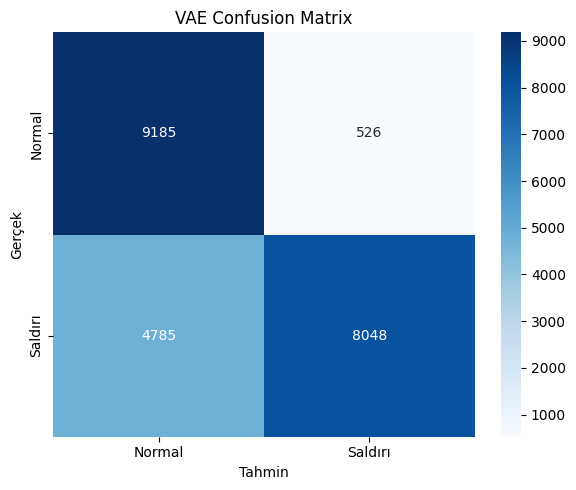

In [13]:
# Test seti için rekonstrüksiyon hatası hesapla
X_test_reconstructed = vae.predict(X_test_scaled)
reconstruction_errors = np.mean(np.power(X_test_scaled - X_test_reconstructed, 2), axis=1)

# Eşik değeri: normal verinin %95. yüzdelik dilimi
X_train_reconstructed = vae.predict(X_train_normal)
train_errors = np.mean(np.power(X_train_normal - X_train_reconstructed, 2), axis=1)
threshold = np.percentile(train_errors, 95)
print(f"Anomali Eşik Değeri (threshold): {threshold:.6f}")

# Tahmin: hata > threshold → saldırı (1), değilse normal (0)
y_pred = (reconstruction_errors > threshold).astype(int)

# METRİKLER
from sklearn.metrics import classification_report
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, reconstruction_errors)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr_score = fp / (fp + tn)

print("\n" + "="*50)
print("        VAE ANOMALİ TESPİT SONUÇLARI")
print("="*50)
print(f"ROC-AUC  : {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"FPR      : {fpr_score:.4f}")
print("\n", classification_report(y_test, y_pred, target_names=['Normal', 'Saldırı']))

# CONFUSION MATRIX
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'])
plt.title('VAE Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig('vae_confusion_matrix.png', dpi=150)
plt.show()

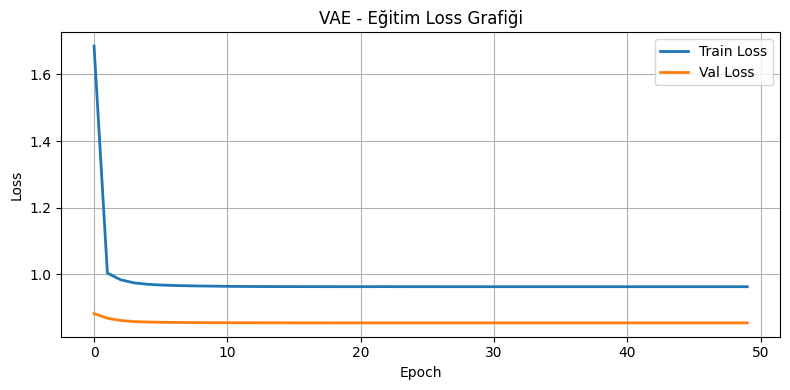

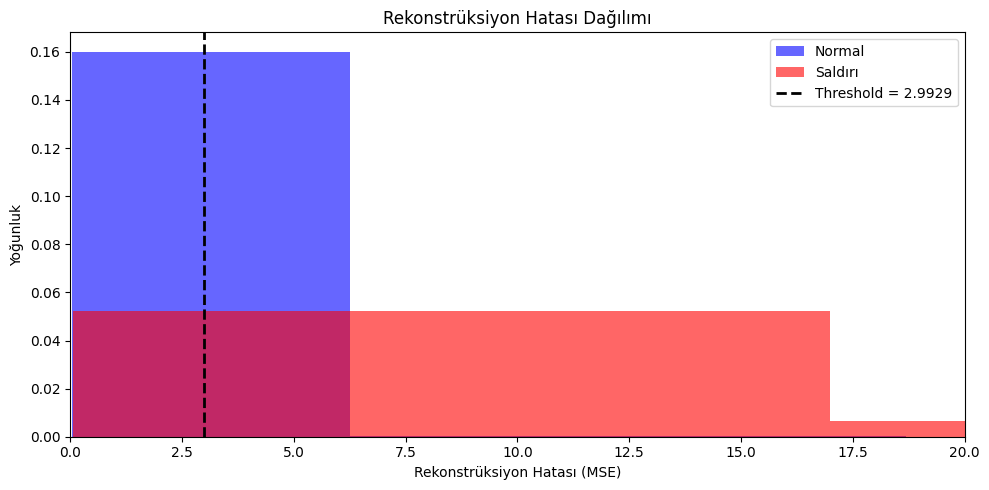

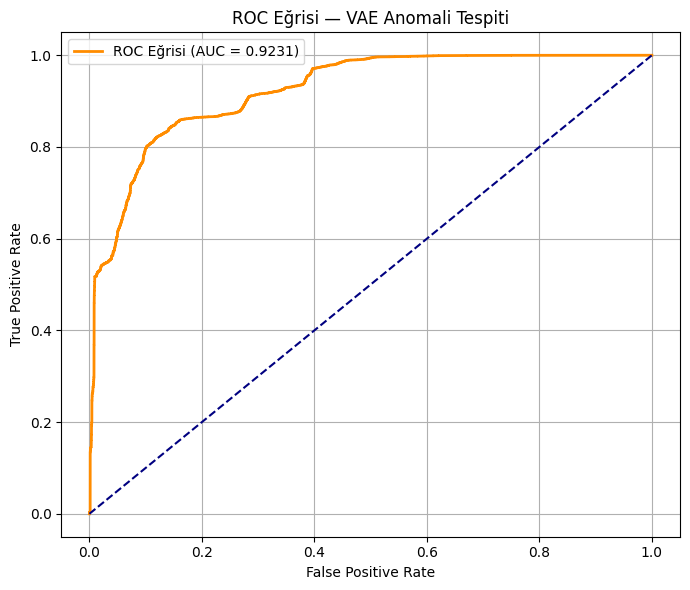

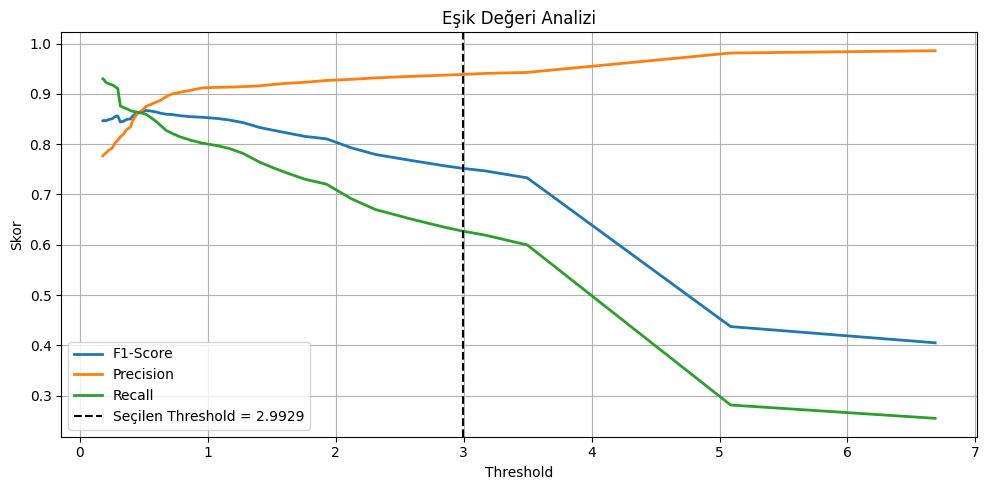

Tüm grafikler oluşturuldu!


In [14]:
#VAE LOSS GRAFİĞİ
plt.figure(figsize=(8, 4))
plt.plot(vae_history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(vae_history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('VAE - Eğitim Loss Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('vae_loss.png', dpi=150)
plt.show()

#REKONSTRÜKSİYON HATASI DAĞILIMI
plt.figure(figsize=(10, 5))
plt.hist(reconstruction_errors[y_test == 0], bins=100, alpha=0.6,
         color='blue', label='Normal', density=True)
plt.hist(reconstruction_errors[y_test == 1], bins=100, alpha=0.6,
         color='red', label='Saldırı', density=True)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.title('Rekonstrüksiyon Hatası Dağılımı')
plt.xlabel('Rekonstrüksiyon Hatası (MSE)')
plt.ylabel('Yoğunluk')
plt.legend()
plt.xlim(0, 20)
plt.tight_layout()
plt.savefig('vae_reconstruction_error.png', dpi=150)
plt.show()

#ROC EĞRİSİ
fpr_arr, tpr_arr, _ = roc_curve(y_test, reconstruction_errors)
plt.figure(figsize=(7, 6))
plt.plot(fpr_arr, tpr_arr, color='darkorange', linewidth=2,
         label=f'ROC Eğrisi (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi — VAE Anomali Tespiti')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('vae_roc_curve.png', dpi=150)
plt.show()

#EŞİK DEĞERİ ANALİZİ
thresholds = np.percentile(train_errors, np.arange(50, 100, 1))
f1_scores, precisions, recalls = [], [], []

for t in thresholds:
    y_p = (reconstruction_errors > t).astype(int)
    f1_scores.append(f1_score(y_test, y_p))
    precisions.append(precision_score(y_test, y_p))
    recalls.append(recall_score(y_test, y_p))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores,  label='F1-Score',  linewidth=2)
plt.plot(thresholds, precisions, label='Precision',  linewidth=2)
plt.plot(thresholds, recalls,    label='Recall',     linewidth=2)
plt.axvline(threshold, color='black', linestyle='--',
            label=f'Seçilen Threshold = {threshold:.4f}')
plt.title('Eşik Değeri Analizi')
plt.xlabel('Threshold')
plt.ylabel('Skor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('vae_threshold_analysis.png', dpi=150)
plt.show()

print("Tüm grafikler oluşturuldu!")